In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, f1_score
from sklearn.preprocessing import LabelEncoder

print("All imports done!")

All imports done!


In [4]:
df = pd.read_csv('../data/cleaned_dataset.csv')

print(f"Rows: {len(df):,}")
print(f"Columns: {df.shape[1]}")
print(f"\nAttack types:")
print(df['Label'].value_counts())

Rows: 882,317
Columns: 80

Attack types:
Label
BENIGN              628638
DoS Hulk            230124
DoS GoldenEye        10293
DoS slowloris         5796
DoS Slowhttptest      5499
Bot                   1956
Heartbleed              11
Name: count, dtype: int64


In [5]:
# Drop non-numeric and label columns
X = df.drop(columns=['Label', 'label_encoded'])
X = X.select_dtypes(include=np.number)

# Target variable
y = df['label_encoded']

print(f"Features (X): {X.shape[1]} columns")
print(f"Labels  (y): {y.nunique()} unique classes")
print(f"\nFeature list sample:")
print(X.columns[:10].tolist())

Features (X): 78 columns
Labels  (y): 7 unique classes

Feature list sample:
['Destination Port', 'Flow Duration', 'Total Fwd Packets', 'Total Backward Packets', 'Total Length of Fwd Packets', 'Total Length of Bwd Packets', 'Fwd Packet Length Max', 'Fwd Packet Length Min', 'Fwd Packet Length Mean', 'Fwd Packet Length Std']


In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,        # 20% for testing
    random_state=42,      # so results are reproducible
    stratify=y            # keeps class ratios balanced
)

print(f"Training rows: {len(X_train):,}")
print(f"Testing rows:  {len(X_test):,}")

Training rows: 705,853
Testing rows:  176,464


In [7]:
print("Training Random Forest... (this will take 3-5 minutes)")

rf_model = RandomForestClassifier(
    n_estimators=100,        # 100 decision trees
    max_depth=20,            # how deep each tree grows
    class_weight='balanced', # handles imbalanced attack data
    random_state=42,
    n_jobs=-1                # uses all your CPU cores
)

rf_model.fit(X_train, y_train)
print("Training complete!")

Training Random Forest... (this will take 3-5 minutes)
Training complete!


In [8]:
y_pred = rf_model.predict(X_test)

le = joblib.load('../ml-engine/label_encoder.pkl')

print("=" * 50)
print("RANDOM FOREST RESULTS")
print("=" * 50)
print(classification_report(y_test, y_pred, target_names=le.classes_))

RANDOM FOREST RESULTS
                  precision    recall  f1-score   support

          BENIGN       1.00      1.00      1.00    125728
             Bot       0.57      0.98      0.72       391
   DoS GoldenEye       1.00      1.00      1.00      2059
        DoS Hulk       1.00      1.00      1.00     46025
DoS Slowhttptest       1.00      0.99      0.99      1100
   DoS slowloris       1.00      0.99      0.99      1159
      Heartbleed       1.00      0.50      0.67         2

        accuracy                           1.00    176464
       macro avg       0.94      0.92      0.91    176464
    weighted avg       1.00      1.00      1.00    176464



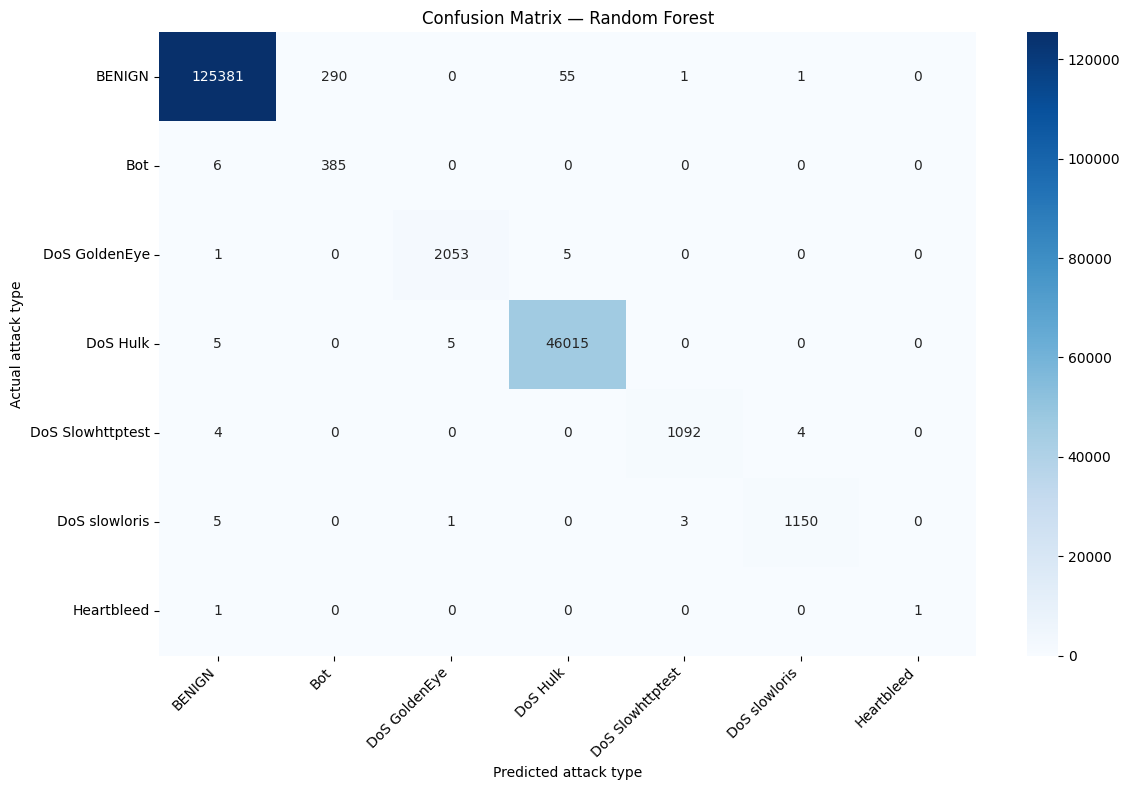

Chart saved!


In [9]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(12, 8))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=le.classes_,
    yticklabels=le.classes_
)
plt.title('Confusion Matrix — Random Forest')
plt.ylabel('Actual attack type')
plt.xlabel('Predicted attack type')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()
print("Chart saved!")

In [10]:
joblib.dump(rf_model, '../ml-engine/random_forest_model.pkl')
joblib.dump(X_train.columns.tolist(), '../ml-engine/feature_names.pkl')

print("Model saved to ml-engine/random_forest_model.pkl")
print("Feature names saved to ml-engine/feature_names.pkl")
print(f"\nModel size: {len(joblib.load('../ml-engine/random_forest_model.pkl').estimators_)} trees")

Model saved to ml-engine/random_forest_model.pkl
Feature names saved to ml-engine/feature_names.pkl

Model size: 100 trees


In [11]:
overall_f1 = f1_score(y_test, y_pred, average='weighted')

print("=" * 40)
print("DAY 2 COMPLETE — Summary")
print("=" * 40)
print(f"Model:        Random Forest")
print(f"Trees:        100")
print(f"Features:     {X_train.shape[1]}")
print(f"Training rows:{len(X_train):,}")
print(f"Test rows:    {len(X_test):,}")
print(f"Overall F1:   {overall_f1:.4f} ({overall_f1*100:.1f}%)")
print("\nFiles saved:")
print("  ml-engine/random_forest_model.pkl")
print("  ml-engine/feature_names.pkl")
print("  ml-engine/label_encoder.pkl")

DAY 2 COMPLETE — Summary
Model:        Random Forest
Trees:        100
Features:     78
Training rows:705,853
Test rows:    176,464
Overall F1:   0.9980 (99.8%)

Files saved:
  ml-engine/random_forest_model.pkl
  ml-engine/feature_names.pkl
  ml-engine/label_encoder.pkl


In [12]:
import requests

# Grab one real row from your test set — a DDoS attack
sample_row = X_test.iloc[0].tolist()
actual_label = le.inverse_transform([y_test.iloc[0]])[0]

response = requests.post(
    "http://127.0.0.1:8000/predict",
    json={"features": sample_row}
)

result = response.json()
print("=" * 40)
print("LIVE API TEST")
print("=" * 40)
print(f"Actual label:  {actual_label}")
print(f"Predicted:     {result['prediction']}")
print(f"Is attack:     {result['is_attack']}")
print(f"Confidence:    {result['confidence']}%")
print(f"Severity:      {result['severity']}")
print(f"\nAPI Response: {result}")

LIVE API TEST
Actual label:  BENIGN
Predicted:     BENIGN
Is attack:     False
Confidence:    100.0%
Severity:      NONE

API Response: {'prediction': 'BENIGN', 'is_attack': False, 'confidence': 100.0, 'severity': 'NONE'}
